# Blocking-Rising K=2 Bandit, Gig Marketplace Simulation

Arm 1 ("experienced"): fixed mean, low variance, **exogenous** sleeping
(each round, if awake, falls asleep w.p. `p_sleep`, checked first; once
asleep stays asleep for exactly `alpha` rounds; pulling it has no effect
on this process at all).

Arm 2 ("novice pool"): always available, rising mean
`mu2(n) = mu2_star * (1 - exp(-v*n))` where `n` = pulls so far.

Regret = "best available arm" regret at each round.

Requires: `bandit_core.py` in the same folder (the numba-jitted engine).
Run `pip install numba matplotlib numpy` if needed.

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from bandit_core import monte_carlo_agg, configure_threads

## Scenario parameters
Edit these and re-run the cells below.

In [4]:
PARAMS = dict(
    T=100000,          # horizon (rounds / job postings)
    n_mc=10000,       # Monte Carlo replications per policy

    # Arm 1: experienced worker pool
    mu1=0.55,         # fixed mean reward
    sigma1=0.15,     # low variance
    p_sleep=0.03,    # per-round prob. of random (exogenous) sleep onset
    alpha=8,         # rounds asleep once triggered (fixed duration)

    # Arm 2: novice worker pool (rising bandit)
    mu2_star=0.6,   # unknown asymptotic mean (algorithms never see this)
    v=0.01,          # rise rate: mu2(n) = mu2_star * (1 - exp(-v n))
    sigma2=0.35,     # higher variance

    ucb_c=1.0,       # UCB exploration constant
    base_seed=2026,
)

POLICIES = {0: "Greedy", 1: "UCB1", 2: "Thompson Sampling"}
COLORS = {0: "tab:red", 1: "tab:blue", 2: "tab:green"}

## Run Monte Carlo simulation for all policies
(parallelized across MC replications via `numba.prange` — uses all available cores)

In [8]:
def run_all(params, n_threads=8, n_sample=150):
    actual_threads = configure_threads(n_threads)
    print(f"[numba] using {actual_threads} thread(s) for Monte Carlo parallelism")

    args_common = (params["mu1"], params["sigma1"], params["p_sleep"], params["alpha"],
                   params["mu2_star"], params["v"], params["sigma2"], params["ucb_c"])

    results = {}
    for pid, name in POLICIES.items():
        t_compile0 = time.time()
        monte_carlo_agg(pid, 2, 10, *args_common, params["base_seed"], n_sample=2)  # tiny warmup
        t_compile = time.time() - t_compile0

        t0 = time.time()
        mean_r, std_r, frac2, final_r, sample_r = monte_carlo_agg(
            pid, params["n_mc"], params["T"], *args_common,
            params["base_seed"] + pid * 100003, n_sample=n_sample,
        )
        elapsed = time.time() - t0
        total_rounds = params["n_mc"] * params["T"]
        print(f"{name:>20s} | warmup(compile)~{t_compile:6.3f}s | "
              f"{params['n_mc']}x{params['T']} = {total_rounds:,} rounds "
              f"in {elapsed:6.3f}s  ({total_rounds/elapsed:,.0f} rounds/s)")

        results[pid] = dict(mean_regret=mean_r, std_regret=std_r,
                             frac_arm2=frac2, final_regret=final_r,
                             sample_regret=sample_r)
    return results


results = run_all(PARAMS, n_threads=8)

[numba] using 8 thread(s) for Monte Carlo parallelism
              Greedy | warmup(compile)~10.659s | 10000x100000 = 1,000,000,000 rounds in 26.818s  (37,288,196 rounds/s)
                UCB1 | warmup(compile)~ 0.000s | 10000x100000 = 1,000,000,000 rounds in 32.660s  (30,618,157 rounds/s)
   Thompson Sampling | warmup(compile)~ 0.001s | 10000x100000 = 1,000,000,000 rounds in 86.661s  (11,539,247 rounds/s)


## Summary stats

In [9]:
def print_summary(results, params):
    print("=== Final cumulative regret (mean +/- std, at T={}) ===".format(params["T"]))
    for pid, name in POLICIES.items():
        final = results[pid]["regret"][:, -1]
        print(f"{name:>20s}: {final.mean():7.3f} +/- {final.std():6.3f}")

print_summary(results, PARAMS)

=== Final cumulative regret (mean +/- std, at T=100000) ===


KeyError: 'regret'

In [10]:
def print_stuck_diagnostic(results, params):
    """Flags runs that never escape arm 1 by T: final regret still near the
    population max. A crude but useful 'did this run get trapped?' proxy."""
    print("=== Stuck-on-arm-1 diagnostic ===")
    for pid, name in POLICIES.items():
        rm = results[pid]["regret"]
        final = rm[:, -1]
        cutoff = np.median(final) + 0.5 * (final.max() - np.median(final))
        stuck_frac = np.mean(final > cutoff)
        print(f"{name:>20s}: {stuck_frac*100:5.1f}% of runs still high-regret "
              f"at T={params['T']}  (final regret range: "
              f"{final.min():.1f} - {final.max():.1f})")

print_stuck_diagnostic(results, PARAMS)

=== Stuck-on-arm-1 diagnostic ===


KeyError: 'regret'

## Plot: mean cumulative regret (±95% CI)

saved regret_curves.png


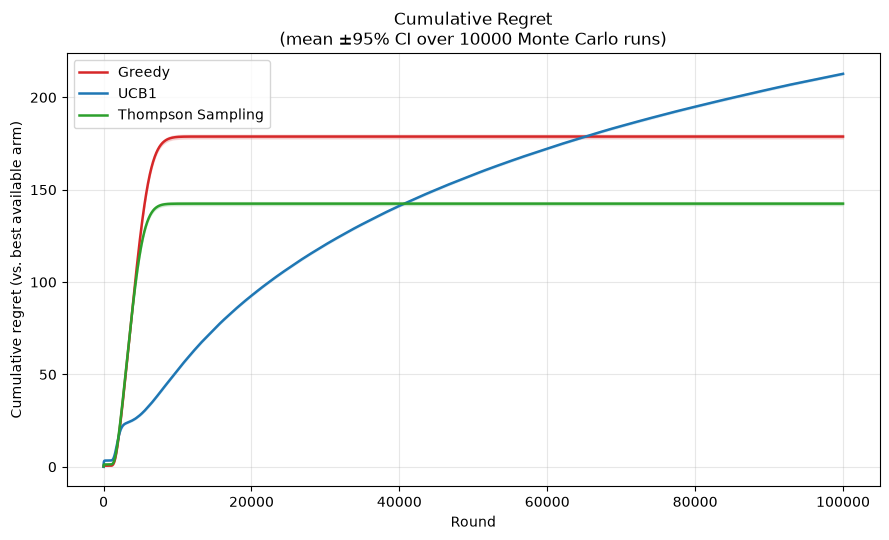

In [11]:
def plot_regret(results, params, outpath=None):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = np.arange(1, params["T"] + 1)
    for pid, name in POLICIES.items():
        mean = results[pid]["mean_regret"]
        std = results[pid]["std_regret"]
        se = std / np.sqrt(params["n_mc"])
        ax.plot(x, mean, label=name, color=COLORS[pid], lw=1.8)
        ax.fill_between(x, mean - 1.96 * se, mean + 1.96 * se,
                         color=COLORS[pid], alpha=0.15)
    ax.set_xlabel("Round")
    ax.set_ylabel("Cumulative regret (vs. best available arm)")
    ax.set_title("Cumulative Regret\n"
                  f"(mean $\\pm$95% CI over {params['n_mc']} Monte Carlo runs)")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=150)
        print(f"saved {outpath}")
    plt.show()

plot_regret(results, PARAMS, outpath="regret_curves.png")

## Plot: arm allocation over time

saved arm_allocation.png


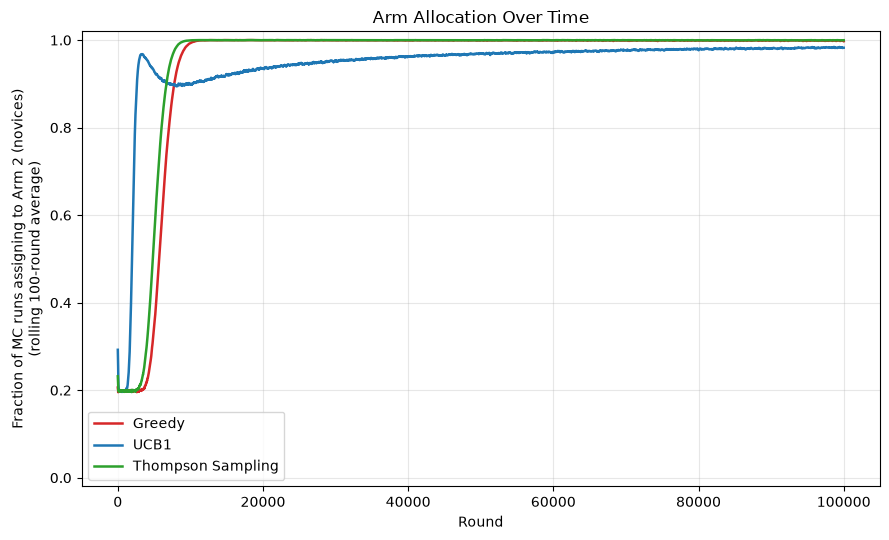

In [12]:
def plot_allocation(results, params, outpath=None, window=100):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = np.arange(1, params["T"] + 1)
    ones_kernel = np.ones(window)
    for pid, name in POLICIES.items():
        frac_arm2 = results[pid]["frac_arm2"]
        summed = np.convolve(frac_arm2, ones_kernel, mode="same")
        counts = np.convolve(np.ones_like(frac_arm2), ones_kernel, mode="same")
        smoothed = summed / counts
        ax.plot(x, smoothed, label=name, color=COLORS[pid], lw=1.8)
    ax.set_xlabel("Round")
    ax.set_ylabel(f"Fraction of MC runs assigning to Arm 2 (novices)\n(rolling {window}-round average)")
    ax.set_title("Arm Allocation Over Time")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=150)
        print(f"saved {outpath}")
    plt.show()

plot_allocation(results, PARAMS, outpath="arm_allocation.png")

## Plot: individual Monte Carlo trajectories per policy

C:\Users\chris\AppData\Local\Temp\ipykernel_5644\1061285769.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
C:\Users\chris\AppData\Local\Temp\ipykernel_5644\1061285769.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(outpath, dpi=150)


saved regret_curves_per_policy.png


c:\Users\chris\OneDrive\Documents\projects\bandits\bandits-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


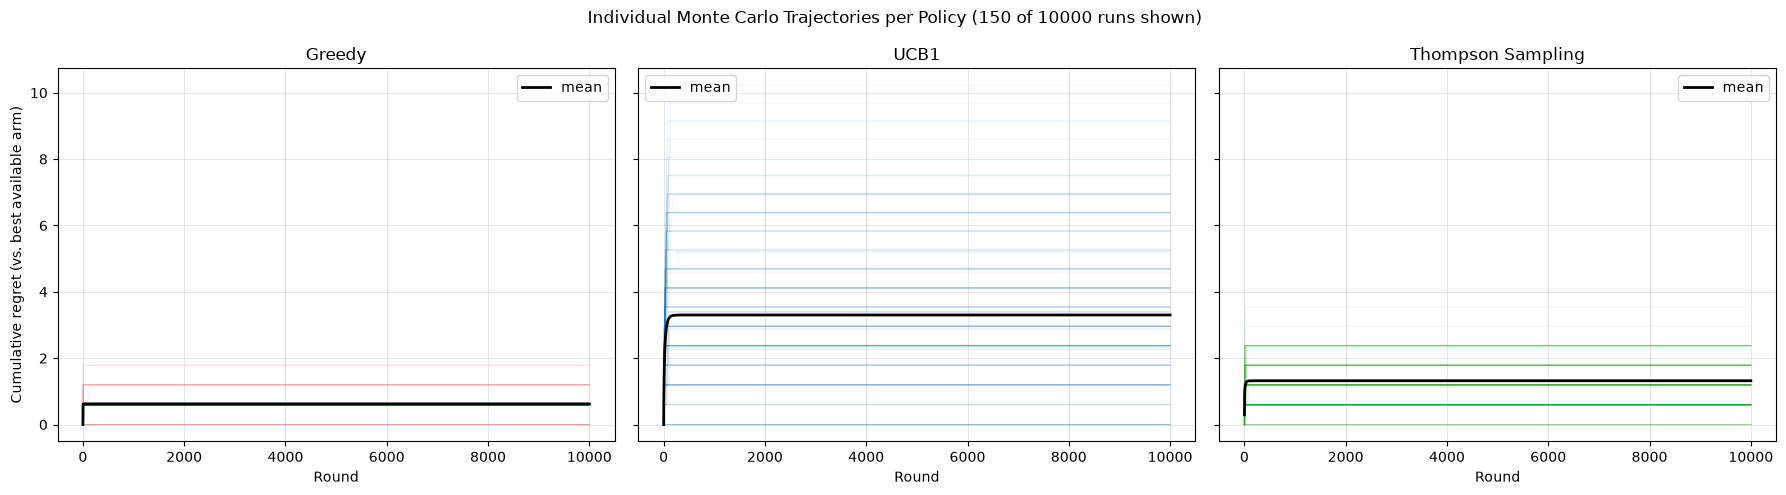

In [33]:
def plot_regret_per_policy(results, params, outpath=None, n_sample=150, seed=0):
    rng = np.random.default_rng(seed)
    n_policies = len(POLICIES)
    fig, axes = plt.subplots(1, n_policies, figsize=(6 * n_policies, 5), sharey=True)
    x = np.arange(1, params["T"] + 1)

    for ax, (pid, name) in zip(axes, POLICIES.items()):
        rm = results[pid]["regret"]
        n_mc = rm.shape[0]
        idx = rng.choice(n_mc, size=min(n_sample, n_mc), replace=False)
        for i in idx:
            ax.plot(x, rm[i, :], color=COLORS[pid], alpha=0.06, lw=0.8)
        mean = rm.mean(axis=0)
        ax.plot(x, mean, color="black", lw=2.0, label="mean")
        ax.set_title(name)
        ax.set_xlabel("Round")
        ax.grid(alpha=0.3)
        ax.legend()

    axes[0].set_ylabel("Cumulative regret (vs. best available arm)")
    fig.suptitle(f"Individual Monte Carlo Trajectories per Policy "
                 f"({min(n_sample, params['n_mc'])} of {params['n_mc']} runs shown)")
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=150)
        print(f"saved {outpath}")
    plt.show()

plot_regret_per_policy(results, PARAMS, outpath="regret_curves_per_policy.png")